In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ydata_profiling

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [37]:
df.isna().sum()[df.isna().sum() > 0]

TotalCharges    11
dtype: int64

### Data Transformation

In [38]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### EDA

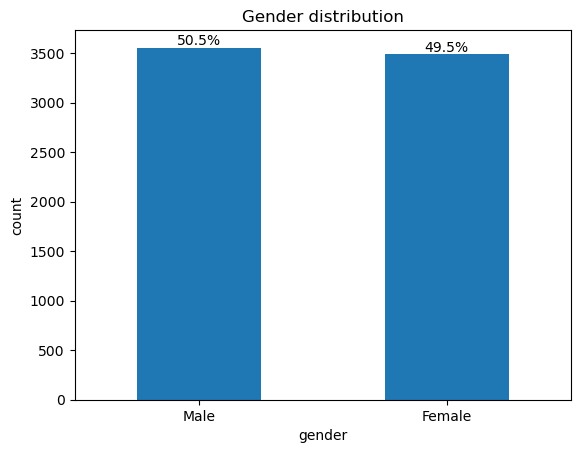

In [40]:
ax = df['gender'].value_counts().plot(kind='bar')

# axis labels
plt.xlabel('gender')
plt.ylabel('count')
plt.title('Gender distribution')
plt.xticks(rotation=0)

# total for percentage calculation
total = len(df)

# add % labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{(count/total)*100:.1f}%'
    
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom')

plt.show()


# Gender distribution is almost equal in dataset.

<Axes: xlabel='Dependents', ylabel='count'>

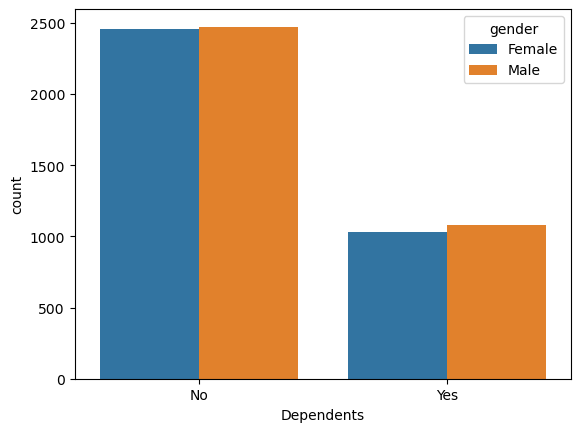

In [55]:
ax2 = (
    df['Dependents'].groupby(df['gender']).value_counts().reset_index(name='count')
)
sns.barplot(data=ax2, x='Dependents', y='count', hue='gender')

# Dependents distribution is not correlated with gender.

Partner,No,Yes
Dependents,,
No,90.085141,48.589065
Yes,9.914859,51.410935


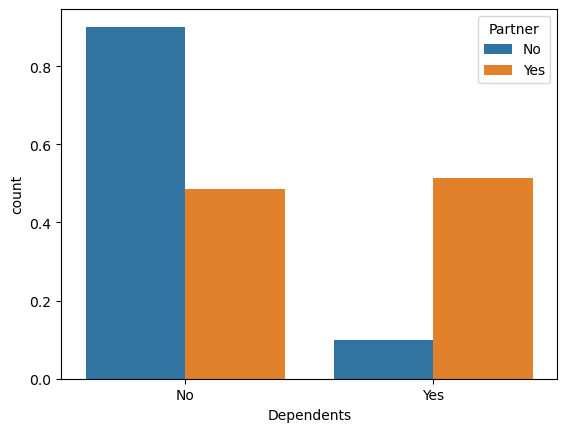

In [69]:
ax3 = (
    df['Dependents'].groupby(df['Partner']).value_counts(normalize=True).reset_index(name='count')
)

sns.barplot(data=ax3, x='Dependents', y='count', hue='Partner')
pd.crosstab(df['Dependents'], df['Partner'],  normalize = 'columns')*100

# 10% of customers have No partner but they are dependent.
# Customers with Partner have equal distribution of dependents and non-dependents.
# We cannot drop any of these columns as they are not highly correlated.

In [52]:
# Ydata profiling report for extensive EDA.

report= ydata_profiling.ProfileReport(df)
report.to_file('Telco_customer_report2.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 212.49it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
#  High correlation between MultipleLines and PhoneService
df['MultipleLines'].groupby(df['PhoneService']).value_counts(normalize=True).reset_index(name='percentage')

# We can drop PhoneService.
# as we can see if MultipleLines is Yes or No then PhoneService is Yes only.

df.drop('PhoneService',axis=1,inplace=True)


In [70]:
pd.crosstab(df['InternetService'], df['OnlineBackup'])
pd.crosstab(df['OnlineSecurity'], df['OnlineBackup'])

# No correlation between InternetService vs OnlineBackup and OnlineSecurity vs OnlineBackup.

OnlineBackup,No,No internet service,Yes
OnlineSecurity,,,
No,2195,0,1303
No internet service,0,1526,0
Yes,893,0,1126


In [75]:
df.groupby('InternetService')['MonthlyCharges'].mean().reset_index()

# Fiber optic is too expensive than DSL.

,InternetService,MonthlyCharges
0,DSL,58.102169
1,Fiber optic,91.500129
2,No,21.079194


In [74]:
# Shares of different InternetService
(df['InternetService'].value_counts(normalize=True)*100).reset_index()

# 44% of market has been captured by Fiber optic and 34% by DSL.
# But huge percentage of customers (22%) have no internet service. So we can target those customers for better marketing strategy.

,InternetService,proportion
0,Fiber optic,43.958540
1,DSL,34.374556
2,No,21.666903


In [85]:
df.groupby('InternetService')['tenure'].value_counts().reset_index().head(20)


,InternetService,tenure,count
0,DSL,1,212
1,DSL,72,133
2,DSL,2,82
3,DSL,3,71
4,DSL,71,62
5,DSL,4,61
6,DSL,70,52
7,DSL,7,46
8,DSL,5,43
9,DSL,8,43


In [28]:
df['Churn'].value_counts(normalize=True)*100

# In given data, Churn rate of customers is 26.5% which is quite high. 

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Churn EDA 

,InternetService,Churn,percentage
0,DSL,No,0.810409
1,DSL,Yes,0.189591
2,Fiber optic,No,0.581072
3,Fiber optic,Yes,0.418928
4,No,No,0.925950
5,No,Yes,0.074050


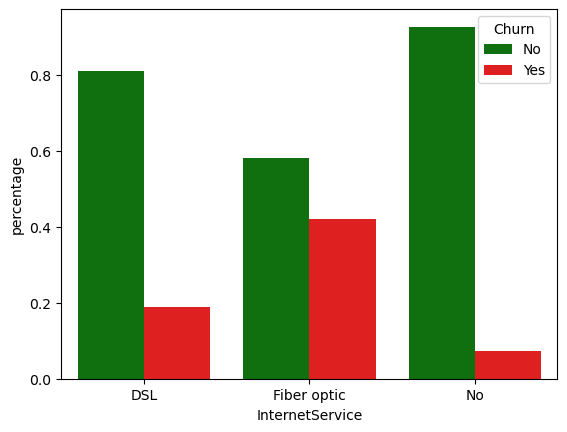

In [ ]:
ax4 = df.groupby('InternetService')['Churn'].value_counts(normalize=True).reset_index(name='percentage')

sns.barplot(data=ax4,
            x='InternetService',
            y='percentage',
            errorbar=None,
            hue='Churn',
            palette=['green', 'red']
            )

# pd.crosstab(df['Churn'], df['InternetService'], normalize='columns')*100
ax4

# Customers with Fiber optic have the highest churn rate (42%)
# DSL customer have higher loyalty (81%) than Fiber optic (58%).

### Fill NA values